# **1. Introduction**

This project aims to build machine learning models that can automatically predict whether a loan application should be approved or denied. The main problem it solves is helping financial institutions make faster and more accurate loan approval decisions by analyzing applicant data.

The motivation behind this project comes from the real-world challenge that banks and lending companies face, they receive thousands of loan applications and must carefully decide whom to approve, balancing risk and fairness. By using machine learning, we can reduce human error, speed up the process, and make data-driven decisions that are more consistent.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
ds = pd.read_csv("Loan Approval Dataset.csv")
ds.head(5)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


# **2. Dataset Description**

**How many features?**

Answer:

In [ ]:
ds.shape[1]

14

In fact, there are 14 features in the dataset.

**Classification or regression problem? Why do you think so?**

Answer:

Classification problem. Because we are predicting two labels from the features.

**How many data points?**

Answer:

In [ ]:
ds.size

630000

In fact, there are 630000 data points.

**What kind of features are in your dataset? (Quantitative / Categorical)**

Answer:

In [ ]:
print(set(ds.dtypes))

{dtype('O'), dtype('float64'), dtype('int64')}


In fact, the features of my dataset are mixed-type, meaning they include both quantitative and categorical variables.

**Correlation of all the features (input and output features) (apply heatmap using the seaborn library):**

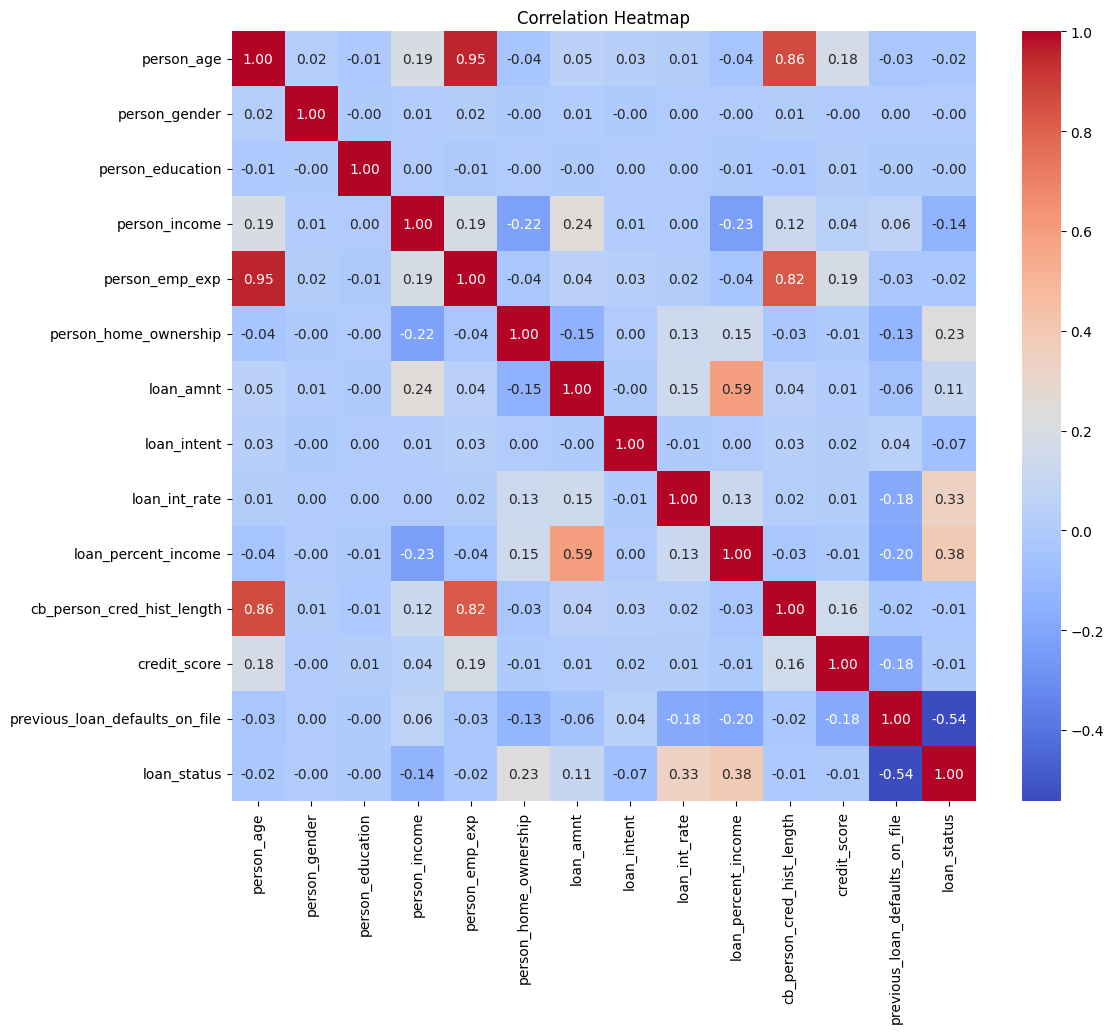

In [ ]:
import seaborn as sns

plt.figure(figsize = (12, 10))
sns.heatmap(ds.corr(), annot = True, cmap = "coolwarm", fmt = ".2f")
plt.title("Correlation Heatmap")
plt.show()

**What do you understand after the correlation test?**

Answer:

previous_loan_defaults_on_file has the strongest correlation with loan_status. This is a strong negative correlation, meaning people with previous loan defaults are much less likely to have their loans approved. This makes sense logically, if someone defaulted before, they are seen as a risk.

loan_int_rate and credit_score show moderate correlation with loan_status. loan_int_rate has a positive correlation (≈ 0.38), suggesting that higher interest rates might be associated with loan approvals, maybe due to higher risk compensation. credit_score has a positive correlation (≈ 0.29), which is expected — better credit scores help approval chances.

Weak or no correlation from variables like person_gender, person_education, or person_home_ownership. These features don’t show a strong relationship with loan approval, which may mean they have little impact or are more useful in combination with other features.

person_emp_exp and person_income are positively correlated with each other and with loan_status, but not strongly. More experience and higher income slightly increase chances of approval.

**For the output feature, do all unique classes have an equal number of instances or not?**

In [ ]:
ds["loan_status"].value_counts()

,count
loan_status,
0,35000
1,10000


In fact, the unique classes don’t have an equal number of instances. The classes in the dataset are imbalanced.

**Represent using a bar chart of N classes (N=number of classes you have in your dataset).**

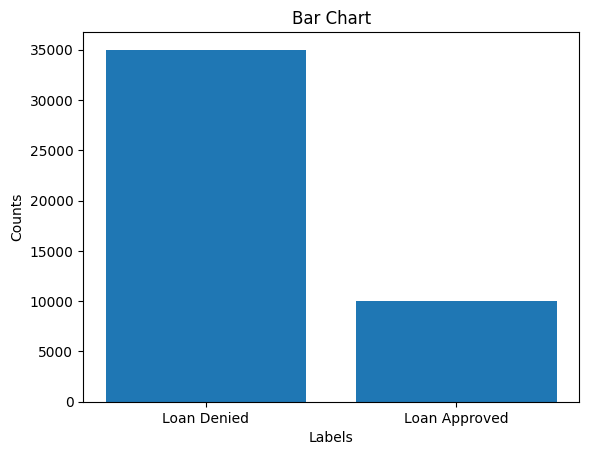

In [ ]:
labels = ["Loan Denied", "Loan Approved"]
values = [35000, 10000]

plt.bar(labels, values)
plt.xlabel("Labels")
plt.ylabel("Counts")
plt.title("Bar Chart")
plt.show()

**Perform exploratory data analysis to extract some important relationships from your data.**

In [ ]:
numerical_data = ds.select_dtypes(include='number')
numerical_data.skew()

,0
person_age,2.548154
person_income,34.137583
person_emp_exp,2.594917
loan_amnt,1.179731
loan_int_rate,0.213784
loan_percent_income,1.034512
cb_person_cred_hist_length,1.631720
credit_score,-0.610261
loan_status,1.336351


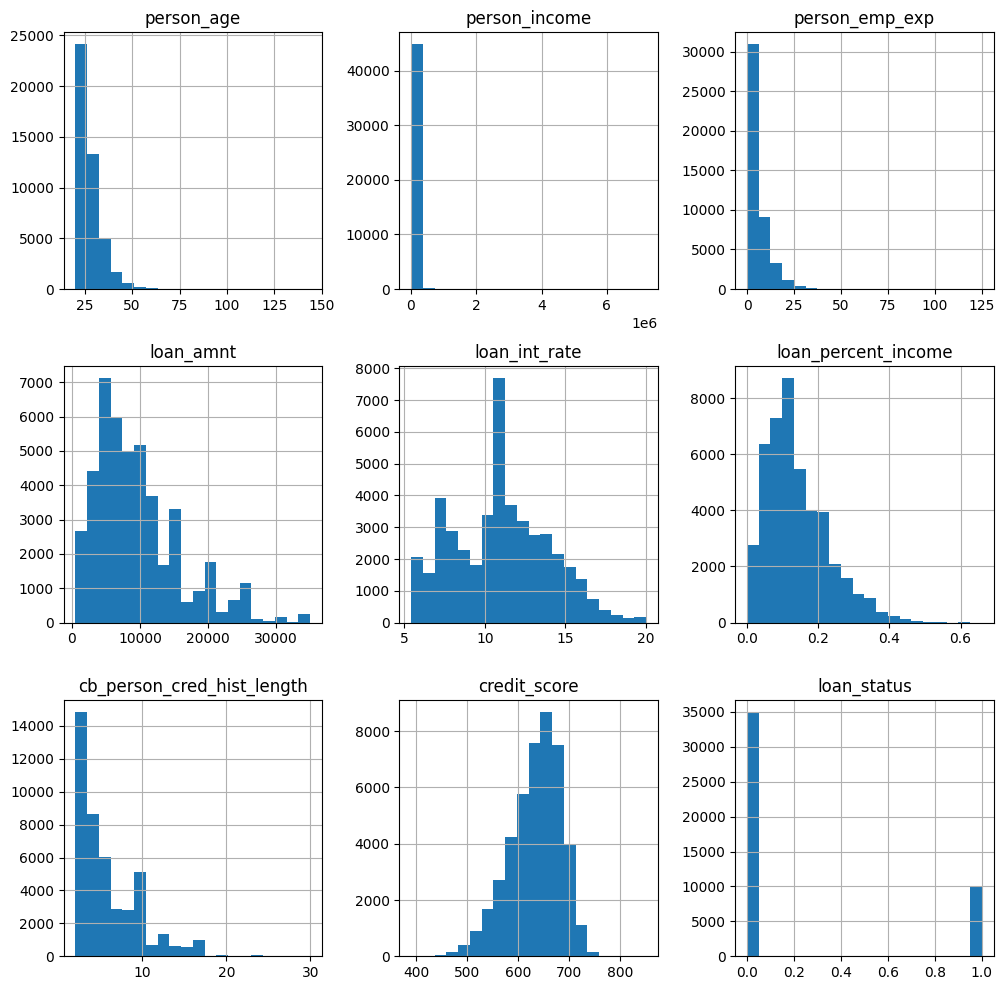

In [ ]:
numerical_data.hist(figsize=(12,12),bins=20)
plt.show()

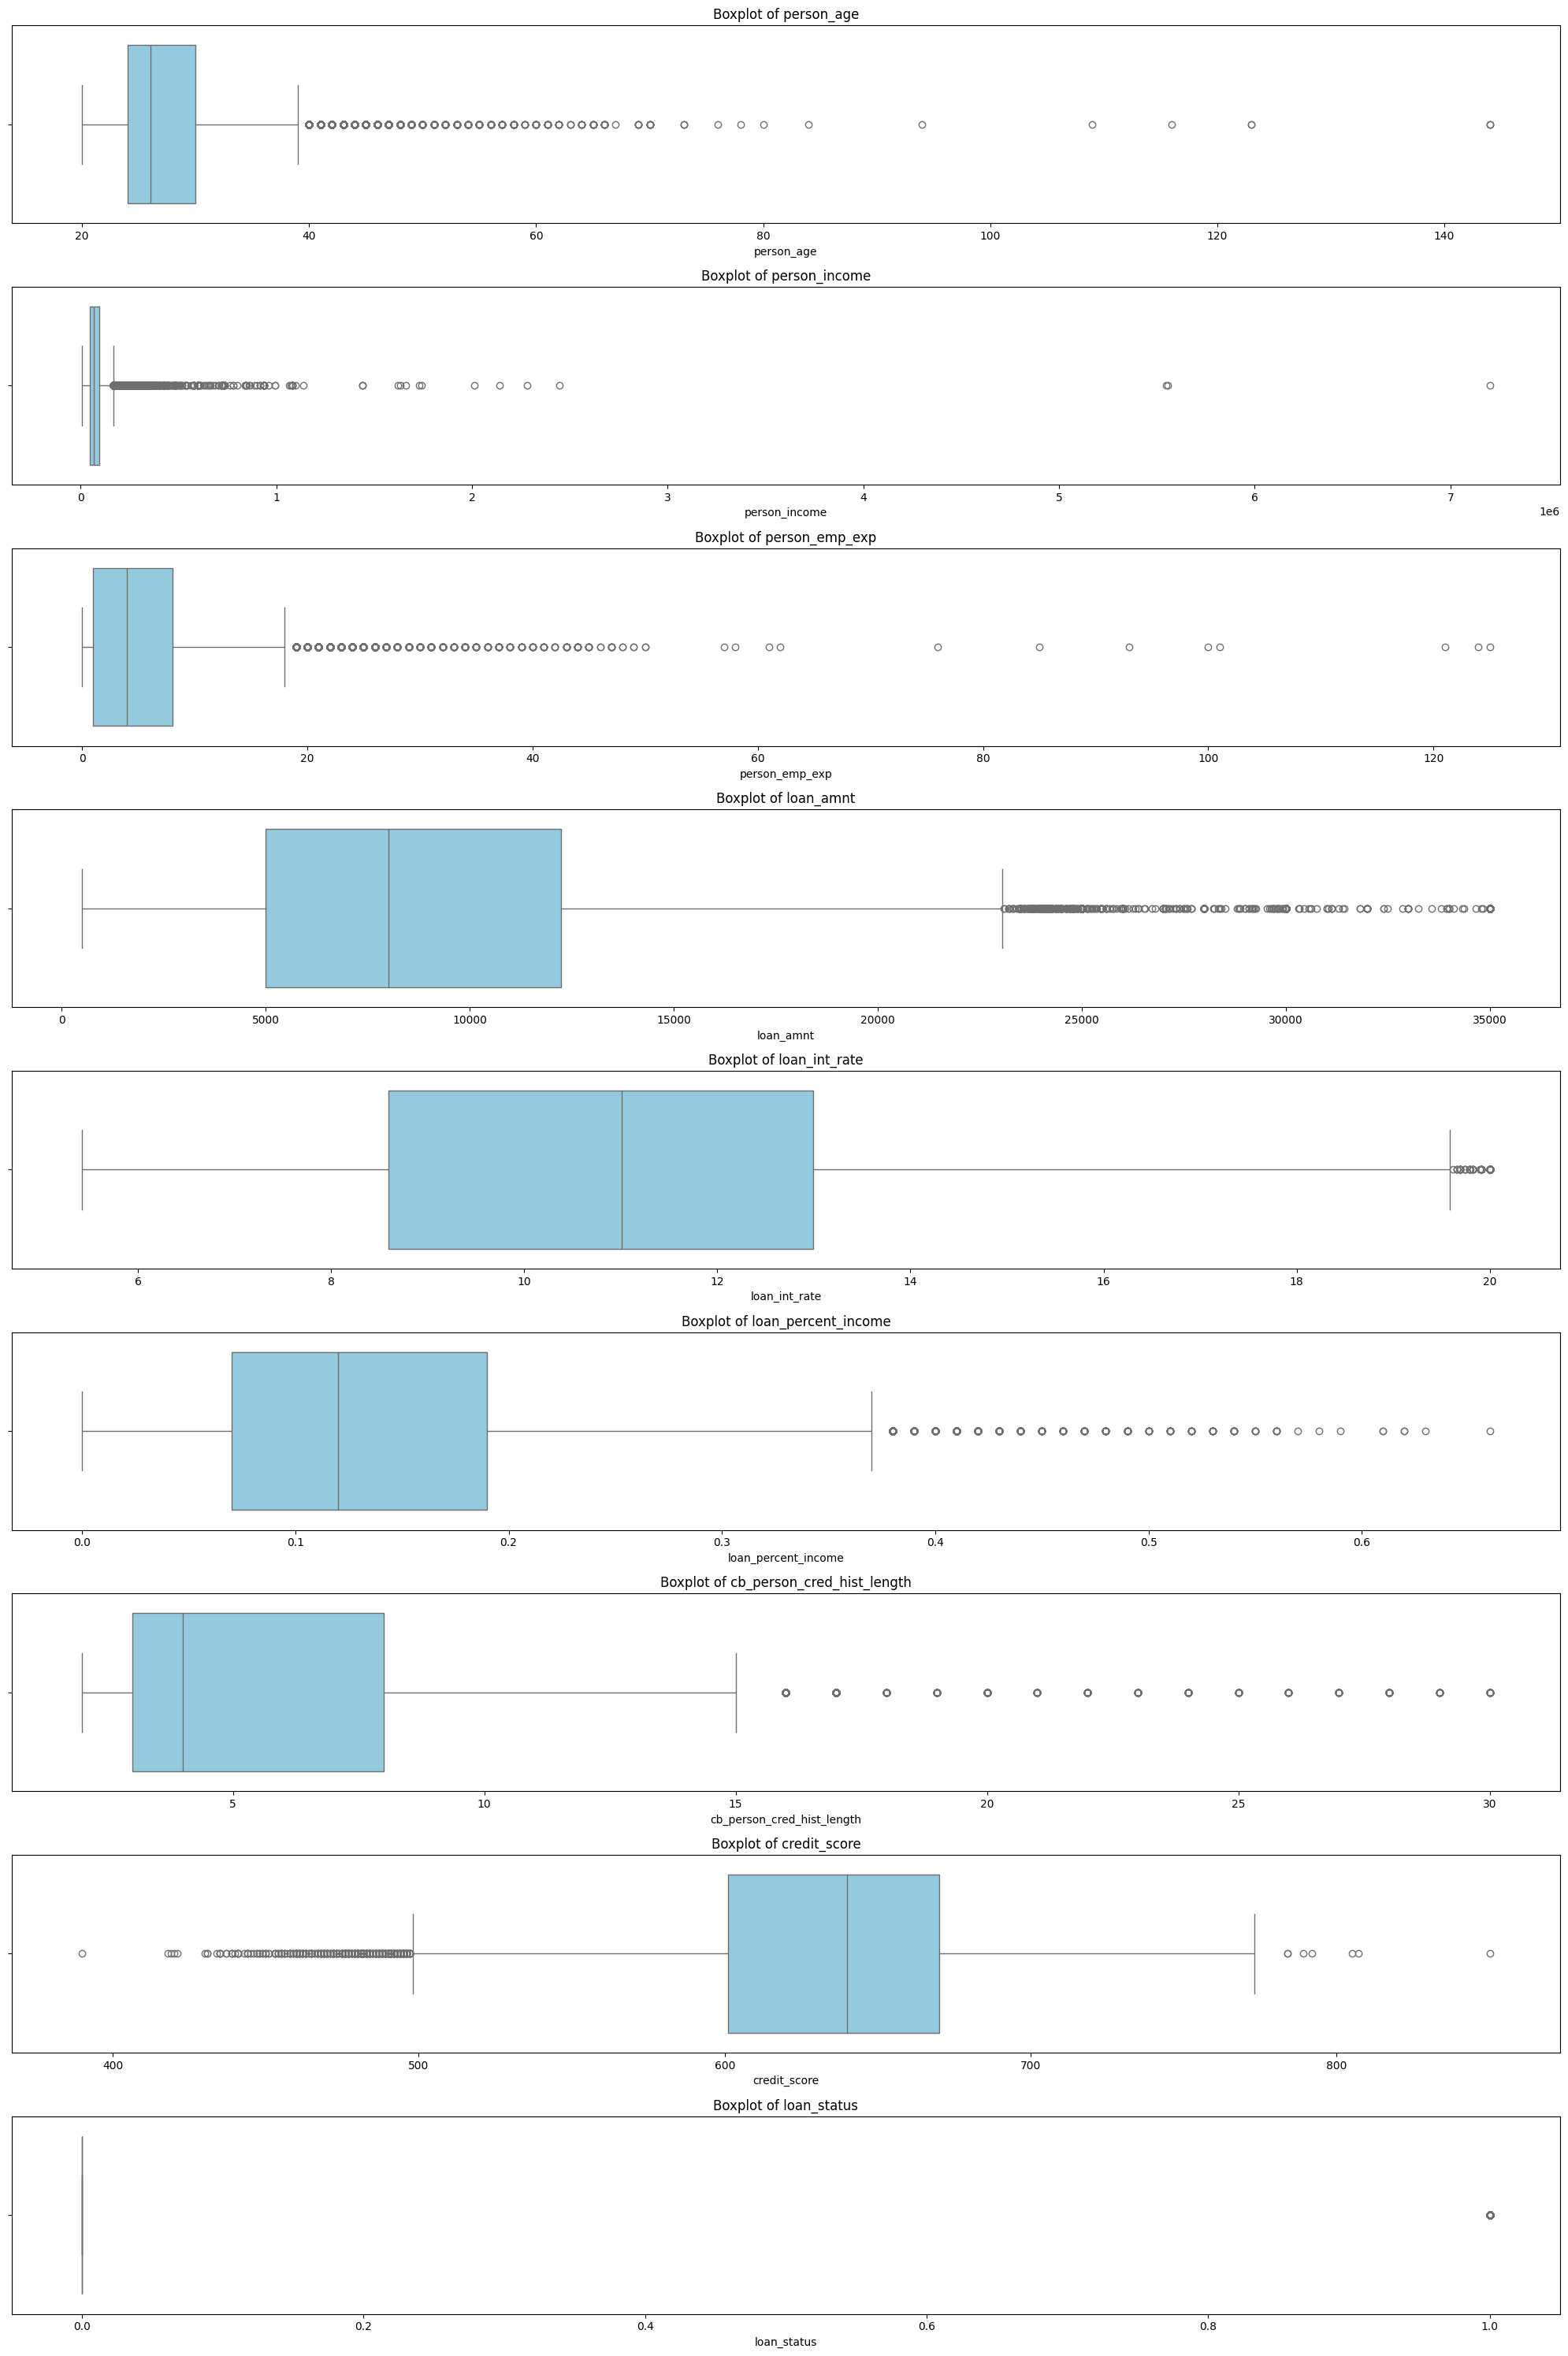

In [ ]:
numeric_cols = ds.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(20, 30))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(x=ds[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.tight_layout()

plt.show()

# **3. Dataset pre-processing**

**Null / Missing values:**

In [ ]:
print(ds.isna().sum())

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64


In fact, there are no null / missing values.

**Categorical values:**

In [ ]:
non_numeric_cols = ds.select_dtypes(exclude=["number"]).columns.tolist()
print(non_numeric_cols)

['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for cat_col in non_numeric_cols:
    ds[cat_col] = le.fit_transform(ds[cat_col])

In [ ]:
ds.dtypes

,0
person_age,float64
person_gender,int64
person_education,int64
person_income,float64
person_emp_exp,int64
person_home_ownership,int64
loan_amnt,float64
loan_intent,int64
loan_int_rate,float64
loan_percent_income,float64


In [ ]:
ds["loan_status"] = ds["loan_status"].astype("int64")

**Feature Scaling:**

In [ ]:
for col in ds.columns.to_list():
    col_var = np.var(ds[col])
    print(f"{col}: {round(col_var, 2)}")

person_age: 36.54
person_gender: 0.25
person_education: 2.19
person_income: 6467634557.79
person_emp_exp: 36.77
person_home_ownership: 2.07
loan_amnt: 39876907.74
loan_intent: 2.99
loan_int_rate: 8.87
loan_percent_income: 0.01
cb_person_cred_hist_length: 15.05
credit_score: 2543.72
previous_loan_defaults_on_file: 0.25
loan_status: 0.17


In [ ]:
y = np.array([0, 1])
y_min = np.min(y)
y_max = np.max(y)

y_normalized = (y - y_min) / (y_max - y_min)

print("Normalized values:", y_normalized)

Normalized values: [0. 1.]


In [ ]:
features = ds.drop("loan_status", axis=1).columns.to_list()
print(features)

['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file']


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
ds[features] = scaler.fit_transform(ds[features])
ds.head(3)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,0.016129,0.0,1.00,0.008891,0.000,1.000000,1.000000,0.8,0.727023,0.742424,0.035714,0.371739,0.0,1
1,0.008065,0.0,0.75,0.000595,0.000,0.666667,0.014493,0.2,0.392318,0.121212,0.000000,0.247826,1.0,0
2,0.040323,0.0,0.75,0.000617,0.024,0.000000,0.144928,0.6,0.510974,0.666667,0.035714,0.532609,0.0,1


In [ ]:
for col in ds.columns.to_list():
    col_var = np.var(ds[col])
    print(f"{col}: {round(col_var, 2)}")

person_age: 0.0
person_gender: 0.25
person_education: 0.14
person_income: 0.0
person_emp_exp: 0.0
person_home_ownership: 0.23
loan_amnt: 0.03
loan_intent: 0.12
loan_int_rate: 0.04
loan_percent_income: 0.02
cb_person_cred_hist_length: 0.02
credit_score: 0.01
previous_loan_defaults_on_file: 0.25
loan_status: 0.17


# **4. Dataset Splitting**

In [ ]:
ds["loan_status"].value_counts()

,count
loan_status,
0,35000
1,10000


In [ ]:
ds_with_0 = ds[ds["loan_status"] == 0]
ds_with_1 = ds[ds["loan_status"] == 1]

In [ ]:
reduce_samp_1 = ds_with_0.sample(n = 10000, replace = False)
ds = pd.concat([reduce_samp_1, ds_with_1])
ds = ds.sample(frac=1)
ds["loan_status"].value_counts()

,count
loan_status,
1,10000
0,10000


In [ ]:
ds.shape

(20000, 14)

In [ ]:
from sklearn.model_selection import train_test_split

x = ds.drop(columns = ["loan_status"])
y = ds["loan_status"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state =1, stratify = y)

# **5. Model Training & Testing**

**Neural Network:**

In [ ]:
!pip install tensorflow

In [ ]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint

In [ ]:
model = Sequential()

model.add(Dense(8, input_shape = (13, ), activation = "relu"))
model.add(BatchNormalization())

model.add(Dense(4, activation = "relu"))

model.add(Dense(1, activation = "sigmoid"))

model.compile(loss = "binary_crossentropy", optimizer = "adam", metrics = ["accuracy"])
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 8)              │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185 (740.00 B)

 Trainable params: 169 (676.00 B)

 Non-trainable params: 16 (64.00 B)

In [ ]:
early_stopping = EarlyStopping(monitor = "val_accuracy", patience = 5, restore_best_weights = True)
model.fit(x_train, y_train, epochs = 10, validation_data = (x_test, y_test), callbacks = [early_stopping])

accuracy = model.evaluate(x_test, y_test)[1]
print(f"Model accuracy is: {round(accuracy, 2)}" )

Epoch 1/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7763 - loss: 0.4603 - val_accuracy: 0.8190 - val_loss: 0.3252
Epoch 2/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8346 - loss: 0.3192 - val_accuracy: 0.8698 - val_loss: 0.2887
Epoch 3/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8638 - loss: 0.2941 - val_accuracy: 0.8723 - val_loss: 0.2812
Epoch 4/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8730 - loss: 0.2822 - val_accuracy: 0.8730 - val_loss: 0.2796
Epoch 5/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8706 - loss: 0.2740 - val_accuracy: 0.8717 - val_loss: 0.2742
Epoch 6/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8686 - loss: 0.2795 - val_accuracy: 0.8723 - val_loss: 0.2730
Epoch 7/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8686 - loss: 0.2759 - val_accuracy: 0.8752 - val_loss: 0.2701
Epoch 8/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8735 - loss: 0.2657 - val_accuracy: 0.

**2 Other models:**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

classifiers = [DecisionTreeClassifier(), RandomForestClassifier()]
clf_accuracies = {}

for model in classifiers:
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    clf_accuracies[type(model).__name__] = round(accuracy, 2)

print("Model Accuracies:")
print(clf_accuracies)

Model Accuracies:
{'DecisionTreeClassifier': 0.86, 'RandomForestClassifier': 0.9}


# **6. Model Selection / Comparison Analysis**

**Bar chart showcasing prediction accuracy of all models:**

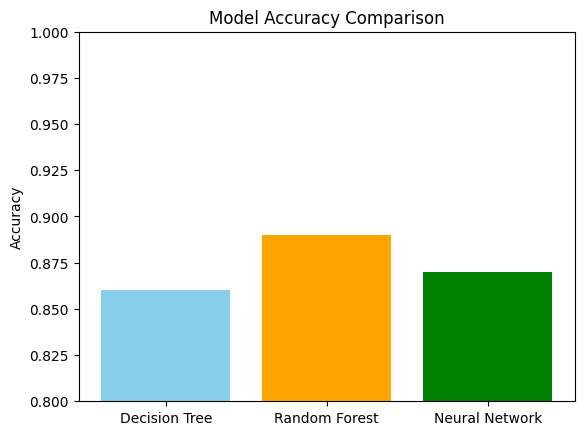

In [ ]:
models = ['Decision Tree', 'Random Forest', 'Neural Network']
accuracies = [0.86, 0.89, 0.87]

plt.bar(models, accuracies, color=['skyblue', 'orange', 'green'])
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim(0.8, 1.0)
plt.show()

**Precision, recall comparison of each model:**

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

classifiers = [DecisionTreeClassifier(), RandomForestClassifier()]
clf_metrics = {}

for model in classifiers:
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    clf_metrics[type(model).__name__] = {
        'Precision': round(precision_score(y_test, y_pred, average='binary'), 2),
        'Recall': round(recall_score(y_test, y_pred, average='binary'), 2),
        'F1 Score': round(f1_score(y_test, y_pred, average='binary'), 2)
    }

print("Precision, Recall, F1 Score:")
for clf, metrics in clf_metrics.items():
    print(f"{clf}: {metrics}")


Precision, Recall, F1 Score:
DecisionTreeClassifier: {'Precision': 0.87, 'Recall': 0.85, 'F1 Score': 0.86}
RandomForestClassifier: {'Precision': 0.89, 'Recall': 0.92, 'F1 Score': 0.9}


**Confusion Matrix:**

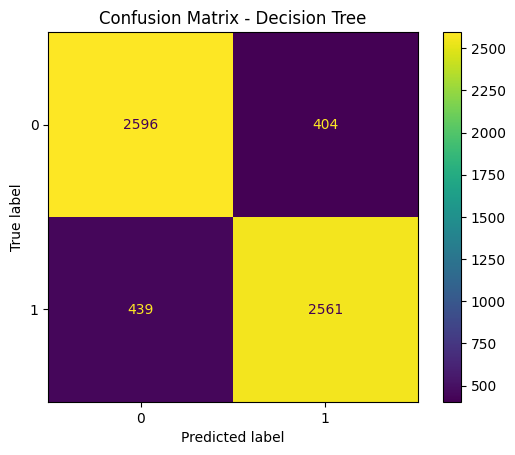

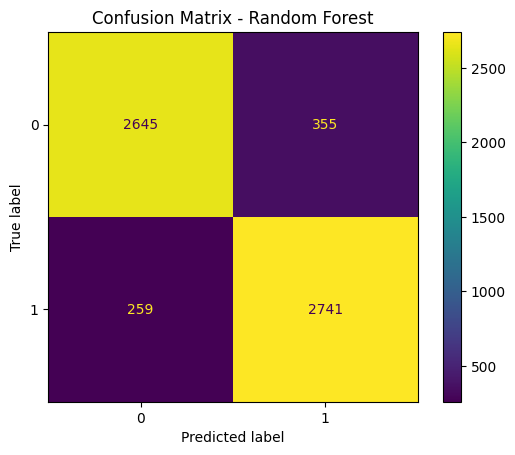

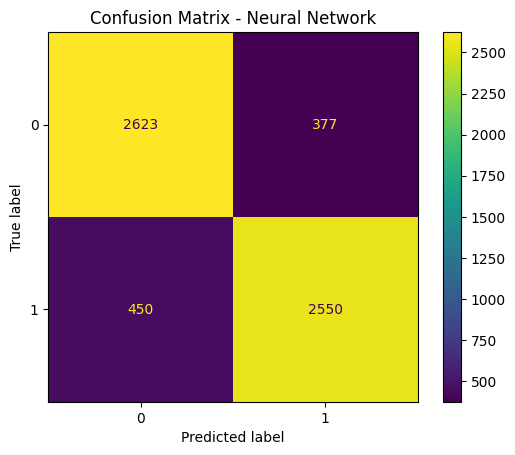

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

classifiers = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Neural Network": DecisionTreeClassifier()
}

for name, model in classifiers.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()


**AUC score, ROC curve:**

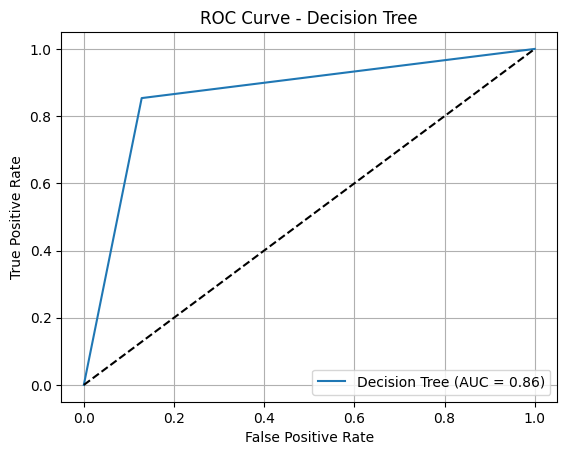

Decision Tree AUC Score: 0.86


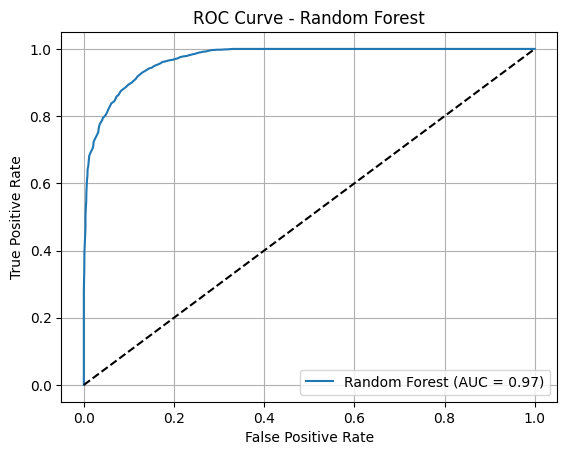

Random Forest AUC Score: 0.97


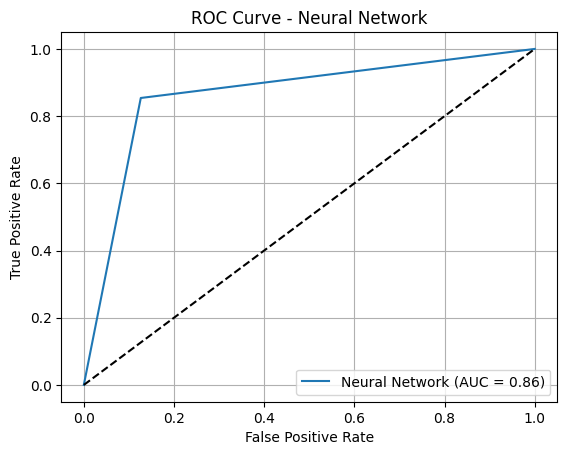

Neural Network AUC Score: 0.86


In [ ]:
from sklearn.metrics import roc_curve, auc

classifiers = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Neural Network": DecisionTreeClassifier()
}

for name, model in classifiers.items():
    model.fit(x_train, y_train)
    y_proba = model.predict_proba(x_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'ROC Curve - {name}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.grid()
    plt.show()

    print(f"{name} AUC Score: {roc_auc:.2f}")

# **7. Conclusion**

**What do you understand from the results?**

Answer:

From the results, I understand that all three models performed well on the classification task. Random Forest had the highest accuracy (0.89), Neural Network was close (0.87), Decision Tree was slightly lower (0.86). This means that all models can correctly classify most of the test data, but Random Forest made the least number of mistakes.

**Make useful comments regarding the performance of your model.**

Answer:

Random Forest performed the best. It avoids overfitting by combining many decision trees and averaging their results. Neural Network also did well, likely because it can learn complex patterns in the data. Decision Tree was simple and fast but may have overfitted a bit, especially if the tree was deep Also, the ROC curves and AUC scores showed that all models have good ability to separate classes.

**Why do you think you are getting such results?**

I think these results happened because Random Forest performed best because it reduces errors by averaging many trees. Also the Neural Network got a good score because of layers, activation functions, and batch normalization, which help in stable learning.

**What are some of the challenges that you have faced?**

Answer:

Some challenges I faced:

1) Handling mixed data types.

2) Training the Neural Network correctly without overfitting.

3) Plotting and comparing results like ROC, AUC, and confusion matrices took some extra time to understand and implement.